<a href="https://colab.research.google.com/github/subhanreddy2007-star/FMML-Projects-and-Labs/blob/main/module3_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a simple, non-parametric, supervised machine learning algorithm that can be used for both classification and regression tasks.
### How it Works:

1. Choose K: Select the number of neighbors (`k`). This is a crucial parameter.
2.  Calculate Distance: For a new data point, calculate the distance (e.g., Euclidean, Manhattan) between this point and every other point in the training dataset.
3.  **Find K Neighbors: Identify the `k` training data points that are closest to the new data point.
4.  **Vote/Average:
   For Classification: Assign the new data point to the class that is most common among its `k`
   For Regression: Predict the value as the average of the target values of its `k` nearest neighbors.

### Advantages:

*   Simple to understand and implement.
*   No assumptions about the underlying data distribution.
*   Works well for multi-class classification problems.

### Disadvantages:

*   Computationally expensive for large datasets (especially during prediction) as it needs to calculate distances to all training points.
*   Sensitive to the local structure of the data and can be affected by noisy or irrelevant features.
*   Requires careful selection of the `k` parameter and distance metric.
*   Sensitive to the scale of the data; features with larger ranges can disproportionately influence the distance calculation.

Let's look at an example implementation using `scikit-learn` in Python.

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of KNN classifier with k=3: {accuracy:.2f}")

new_flower = [[5.1, 3.5, 1.4, 0.2]]
predicted_class = knn.predict(new_flower)

class_names = iris.target_names
print(f"\nNew flower features: {new_flower[0]}")
print(f"Predicted species: {class_names[predicted_class[0]]}")

iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]
display(iris_df.head())

Accuracy of KNN classifier with k=3: 1.00

New flower features: [5.1, 3.5, 1.4, 0.2]
Predicted species: setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Data Visualization

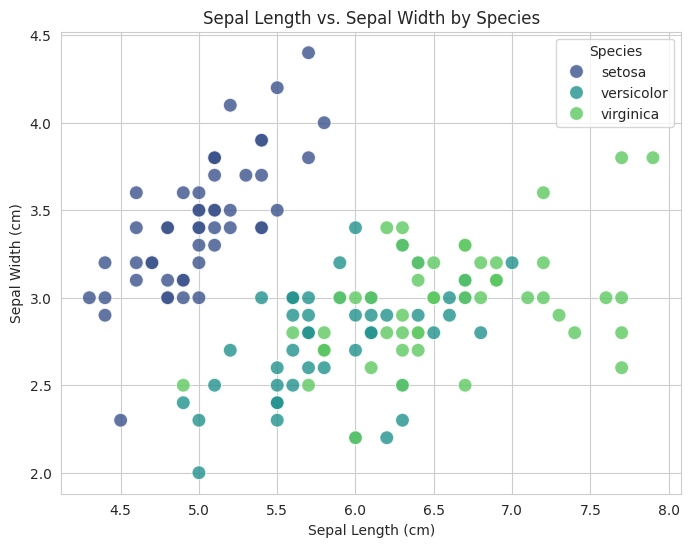

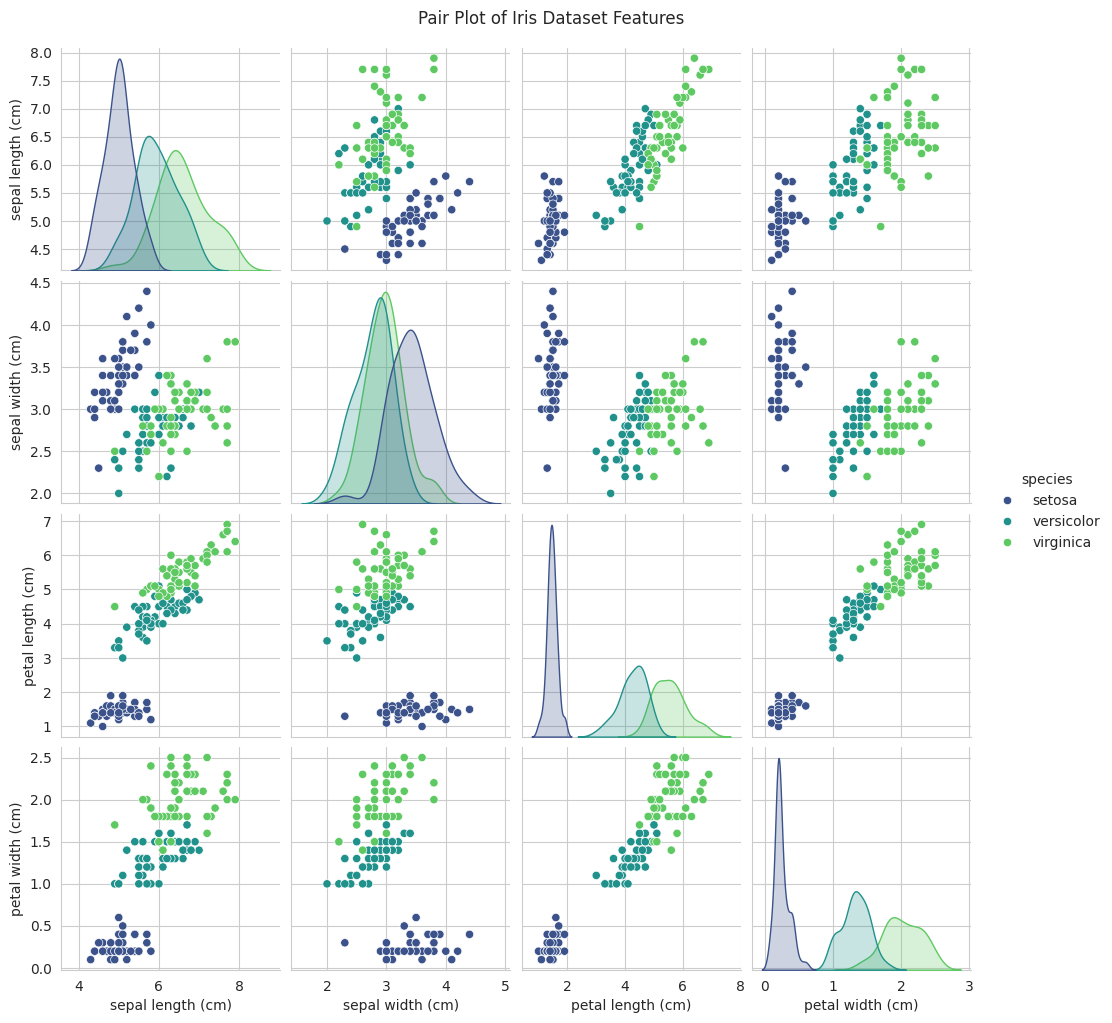

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='species', data=iris_df, palette='viridis', s=100, alpha=0.8)
plt.title('Sepal Length vs. Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.show()

sns.pairplot(iris_df, hue='species', palette='viridis')
plt.suptitle('Pair Plot of Iris Dataset Features', y=1.02)
plt.show()

### Using `ListedColormap` for Custom Palettes

`matplotlib.colors.ListedColormap` allows you to create custom colormaps from a list of color specifications. This can be very useful for ensuring consistency in your plots or highlighting specific categories with distinct colors.

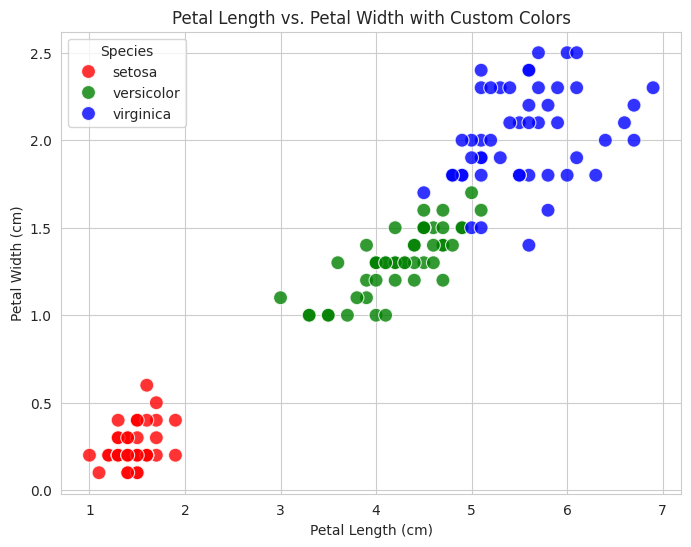

In [11]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns

custom_colors = ['red', 'green', 'blue']

custom_cmap = ListedColormap(custom_colors)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    data=iris_df,
    palette=custom_colors,
    s=100,
    alpha=0.8
)
plt.title('Petal Length vs. Petal Width with Custom Colors')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.show()

### Implementing Custom Distance Metrics: Minkowski Distance

As requested, here's an implementation of the Minkowski distance formula. This function allows you to calculate the distance between two points, `x1` and `x2`, in a D-dimensional space, with a given parameter `p`.

*   When `p=1`, it computes the Manhattan distance.
*   When `p=2`, it computes the Euclidean distance.

In [12]:
import numpy as np

def minkowski_distance(x1, x2, p):
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)

    if x1.shape != x2.shape:
        raise ValueError("Input points must have the same dimensions")

    distance = np.sum(np.abs(x1 - x2)**p)**(1/p)
    return distance

point_a = np.array([1, 2, 3])
point_b = np.array([4, 5, 6])

manhattan_dist = minkowski_distance(point_a, point_b, p=1)
print(f"Manhattan distance between {point_a} and {point_b}: {manhattan_dist:.2f}")

euclidean_dist = minkowski_distance(point_a, point_b, p=2)
print(f"Euclidean distance between {point_a} and {point_b}: {euclidean_dist:.2f}")

custom_p_dist = minkowski_distance(point_a, point_b, p=3)
print(f"Minkowski distance (p=3) between {point_a} and {point_b}: {custom_p_dist:.2f}")

Manhattan distance between [1 2 3] and [4 5 6]: 9.00
Euclidean distance between [1 2 3] and [4 5 6]: 5.20
Minkowski distance (p=3) between [1 2 3] and [4 5 6]: 4.33


### Problem 2: Visualizing Decision Boundaries

**Task 2.1: Create a function that visualizes the decision boundary of a KNN classifier on 2D data.**

This function will help us understand how the KNN algorithm classifies new data points by showing the regions assigned to each class. We'll use the `iris_df` and select two features (e.g., petal length and petal width) to create a 2D plot.

/tmp/ipykernel_2938/3310106562.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
/tmp/ipykernel_2938/3310106562.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


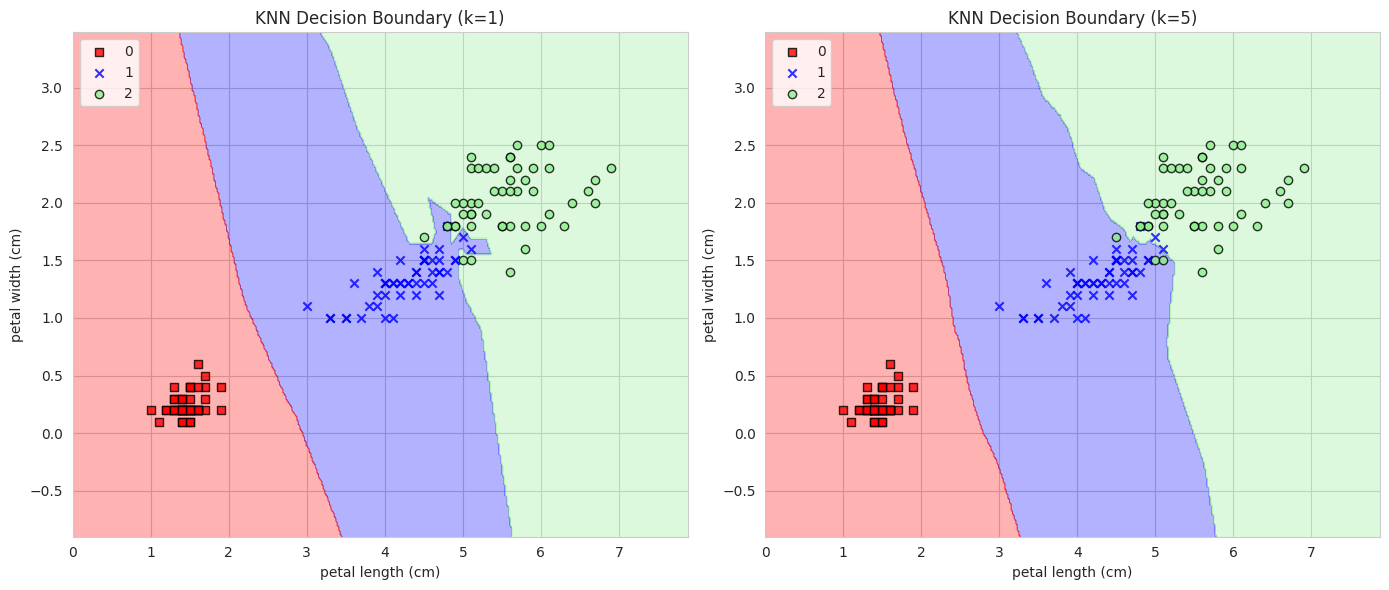

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

def plot_decision_boundary(X, y, classifier, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx], label=cl, edgecolor='black')

features = ['petal length (cm)', 'petal width (cm)']
X_2d = iris_df[features].values
y_2d = iris_df['species'].astype('category').cat.codes.values

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
knn_k1 = KNeighborsClassifier(n_neighbors=1)
knn_k1.fit(X_2d, y_2d)
plot_decision_boundary(X_2d, y_2d, knn_k1)
plt.title('KNN Decision Boundary (k=1)')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
knn_k5 = KNeighborsClassifier(n_neighbors=5)
knn_k5.fit(X_2d, y_2d)
plot_decision_boundary(X_2d, y_2d, knn_k5)
plt.title('KNN Decision Boundary (k=5)')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Problem 3: Impact of Distance Metrics on High-Dimensional Data

**Task 3.1: Create a function that generates random high-dimensional data and compares how different distance metrics behave as dimensionality increases.**

The "curse of dimensionality" is a significant challenge in machine learning, particularly when dealing with distance-based algorithms like KNN. In high-dimensional spaces, the data points become very sparse, and the concept of "distance" can become less intuitive. One common manifestation is that the ratio between the maximum and minimum distances between points tends to approach 1. This means all points become almost equidistant from each other, making it difficult to distinguish between 'near' and 'far' neighbors.

Let's create a function to illustrate this phenomenon with Minkowski distances (Euclidean and Manhattan being special cases).

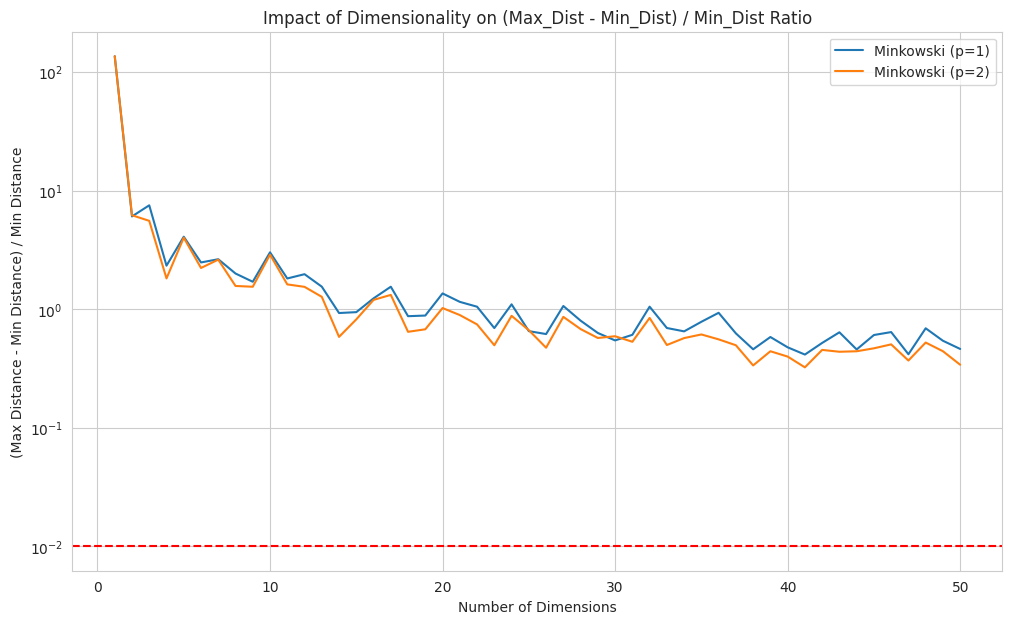

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def compare_distance_metrics_high_dim(num_points=100, max_dimensions=100, p_values=[1, 2]):
    dimensions = np.arange(1, max_dimensions + 1)
    results = {p: [] for p in p_values}

    for dim in dimensions:
        data = np.random.rand(num_points, dim)

        for p in p_values:
            distances = []
            if num_points > 1:
                ref_point = data[0]
                for i in range(1, num_points):
                    distances.append(minkowski_distance(ref_point, data[i], p))

            if distances:
                distances = np.array(distances)
                min_dist = np.min(distances)
                max_dist = np.max(distances)

                if min_dist > 0:
                    results[p].append((max_dist - min_dist) / min_dist)
                else:
                    results[p].append(np.nan)
            else:
                results[p].append(np.nan)

    plt.figure(figsize=(12, 7))
    for p, ratios in results.items():
        plt.plot(dimensions[:len(ratios)], ratios, label=f'Minkowski (p={p})')

    plt.title('Impact of Dimensionality on (Max_Dist - Min_Dist) / Min_Dist Ratio')
    plt.xlabel('Number of Dimensions')
    plt.ylabel('(Max Distance - Min Distance) / Min Distance')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.axhline(y=0.01, color='r', linestyle='--', label='Ratio approaches 0 (near 1)')
    plt.show()

compare_distance_metrics_high_dim(num_points=50, max_dimensions=50, p_values=[1, 2])

Question

1)the draw back of using knn is computational cost and memory
.it causes poor pormormance as the fratures increase